# Glucose Readings 

In [1]:
%run constants.ipynb
%run read_sheet.ipynb
%run clean_functions.ipynb

In [112]:
df = read_sheet(sheet_id=SHEET_2025, col_range="Glucose!A:ZZ")
df.rename(columns=lambda x: x.lower(), inplace=True)

In [113]:
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"], errors="coerce")
df = df[df["timestamp"].notnull()]
df.set_index("timestamp", inplace=True)
df.sort_index(inplace=True)

df["date"] = pd.to_datetime(df["date"])
df["day"] = df.index.strftime("%Y-%m-%d")

df["glucose"] = pd.to_numeric(df["glucose"])
# lines with food etc are helpful for more manual analyses, but not here
df = df[df["glucose"].notnull()]

In [133]:
def glucose_scatterplot(plot_data: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor="w")
    sns.scatterplot(
        x=plot_data.index,
        y=plot_data["glucose"],
    )
    
    plt.axhline(y=70, color="red", linestyle="--")
    plt.axhline(y=80, color="orange", linestyle="--")
    plt.axhline(y=140, color="orange", linestyle="--")
    plt.axhline(y=160, color="red", linestyle="--")

    plt.title("Glucose", size=14)
    plt.xlabel("Date", size=12)
    plt.ylabel("Glucose")
    fig.autofmt_xdate()

In [ ]:
def glucose_lineplot(plot_data: pd.DataFrame, day: str):
    fig, ax = plt.subplots(figsize=(12, 8), facecolor="w")
    sns.lineplot(
        x=plot_data.index,
        y=plot_data["glucose"],
        marker="o",
        estimator=None,
    )

    plt.title(f"Glucose on {day}", size=14)
    plt.xlabel("Time", size=12)
    plt.ylabel("Glucose")
    fig.autofmt_xdate()

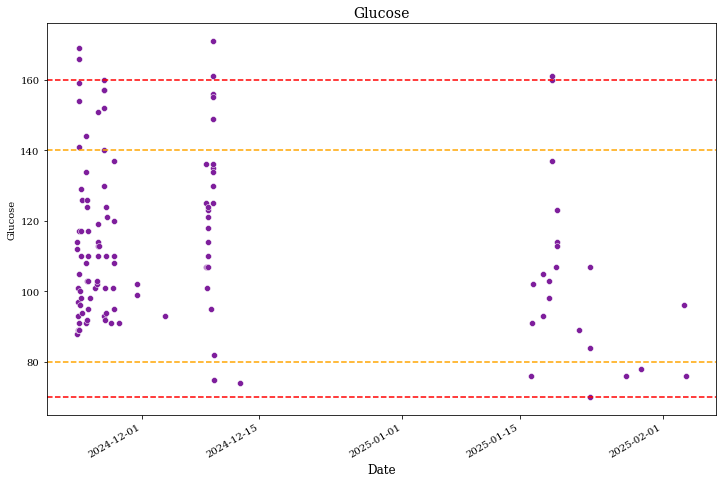

In [134]:
glucose_scatterplot(df)

In [118]:
# Zoom in on a single day with a lot of readings
def plot_day(df: pd.DataFrame, day: str):
    plot_data = df[df["day"] == day].copy()
    glucose_lineplot(plot_data, day)

In [124]:
min_obs = 10

top_days = df["day"].value_counts()
top_days = top_days[top_days >= min_obs].index

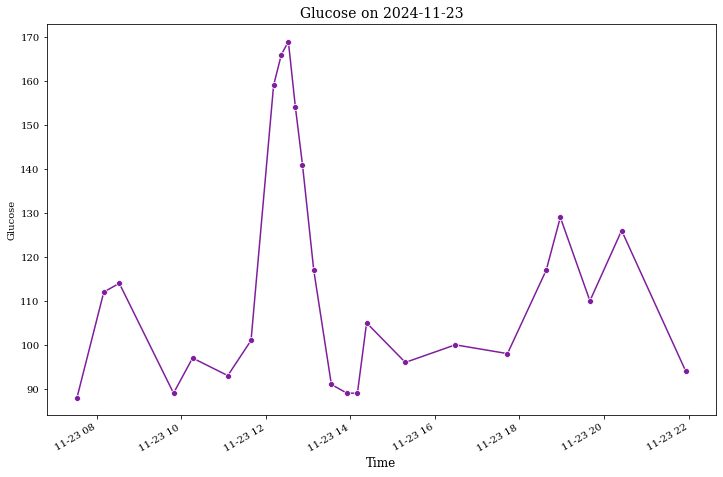

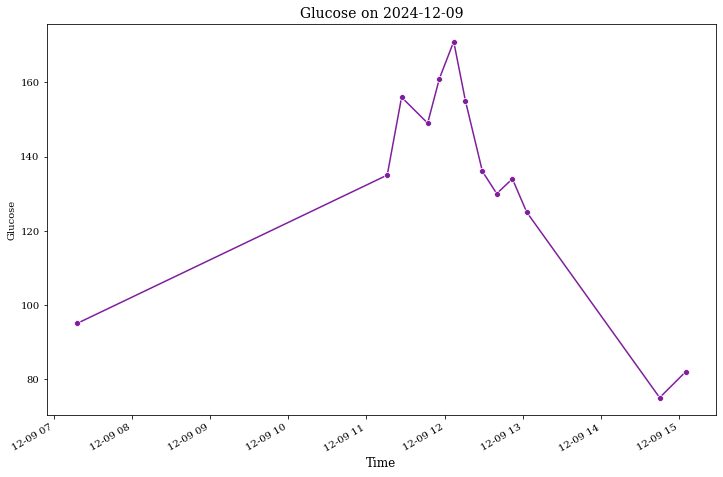

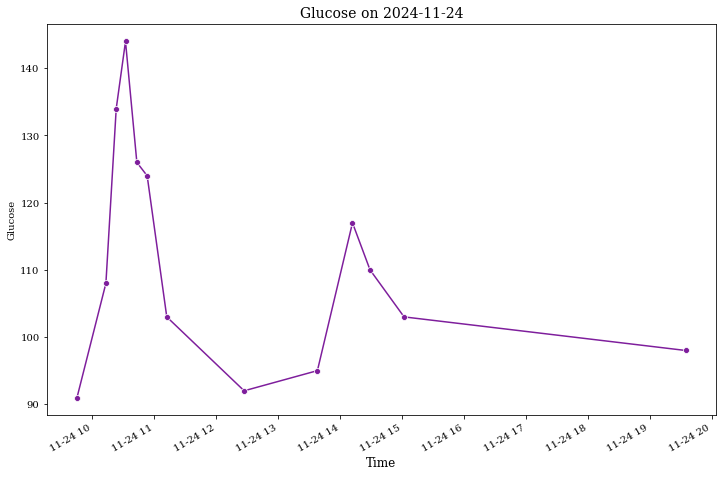

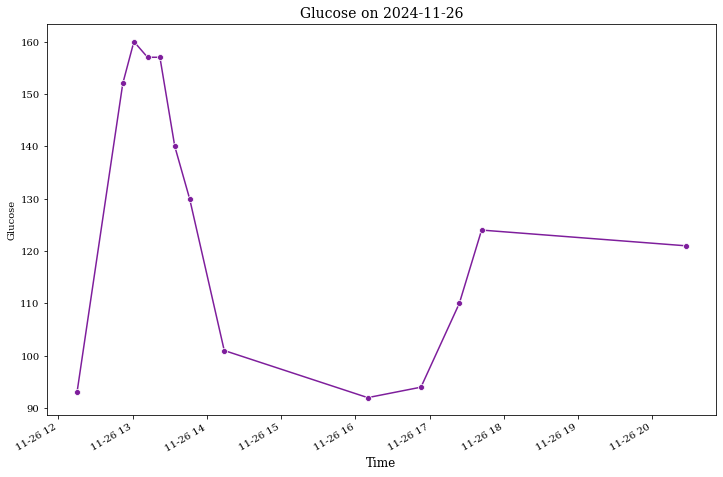

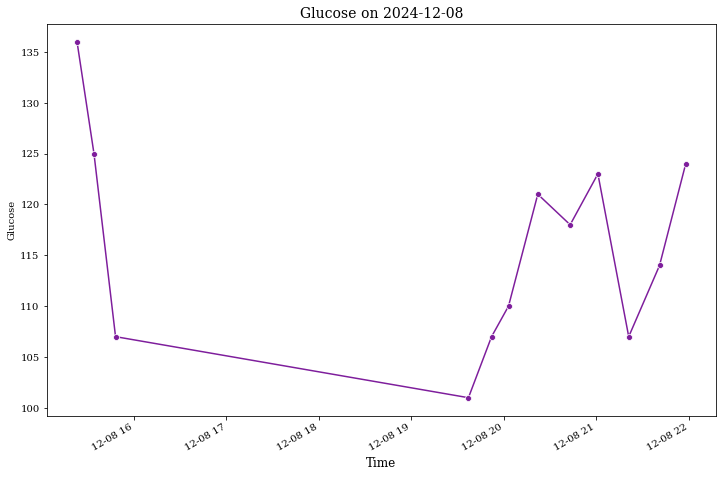

In [126]:
for day in top_days:
    plot_day(df, day)